# LightGBM Parameter Experiment

Evaluate whether a lower learning rate with more boosting rounds improves the Medium-feature LightGBM model while keeping the feature set, target, training period, purge period, and validation period unchanged.

## Research Question

Can a lower learning rate and more boosting rounds improve out-of-sample Numerai CORR?

## Experimental Setup

- **Feature set:** Medium (780 features)
- **Target:** Default Numerai target (`target_ender_60`)
- **Training eras:** `0001–0558`
- **Purged eras:** `0559–0574`
- **Validation eras:** `0575–1221`
- **Test eras:** `1222–1234` (untouched)

The main model changes are the learning rate and number of boosting rounds.

## Experiment Results

| Version | Features | Model | n_estimators | Learning Rate | Mean CORR | CORR Std | Sharpe-like | Positive Eras |
|---|---|---|---:|---:|---:|---:|---:|---:|
| v0 | Small (42) | LightGBM | 300 | 0.05 | 0.017655 | 0.014758 | 1.196 | 87.48% |
| v1 | Medium (780) | LightGBM | 300 | 0.05 | 0.019724 | 0.015247 | 1.294 | 89.80% |
| v2 | Medium (780) | LightGBM | 500 | 0.03 | 0.019704 | 0.015050 | 1.309 | 90.26% |

## 1. Load Feature Metadata

In [1]:
from pathlib import Path
import json

FEATURES_PATH = Path("../data/features.json")

with open(FEATURES_PATH, "r", encoding="utf-8") as f:
    feature_metadata = json.load(f)

medium_features = feature_metadata["feature_sets"]["medium"]

print("Medium features:", len(medium_features))

Medium features: 780


## 2. Load Medium Training and Validation Data

In [2]:
import pandas as pd

TRAIN_PATH = Path("../data/train.parquet")
VALIDATION_PATH = Path("../data/validation.parquet")

train_cols = ["era", "target"] + medium_features
validation_cols = ["era", "data_type", "target"] + medium_features

train_medium = pd.read_parquet(
    TRAIN_PATH,
    columns=train_cols,
)

validation_medium = pd.read_parquet(
    VALIDATION_PATH,
    columns=validation_cols,
)

validation_medium = validation_medium[
    validation_medium["data_type"] == "validation"
].copy()

print("Train shape:", train_medium.shape)
print("Validation shape:", validation_medium.shape)

Train shape: (2746268, 782)
Validation shape: (4036034, 783)


## 3. Prepare Metadata and Apply Purge

In [3]:
PURGE_ERAS = 16

validation_eras = validation_medium["era"].copy()
y_valid = validation_medium["target"].copy()

validation_start_era = int(validation_eras.min())
train_end_era = validation_start_era - PURGE_ERAS - 1

train_medium_purged = train_medium[
    train_medium["era"].astype(int) <= train_end_era
].copy()

print("Training eras:", train_medium_purged["era"].nunique())
print("Last training era:", train_medium_purged["era"].max())
print("Validation eras:", validation_eras.nunique())
print("First validation era:", validation_eras.min())
print("Last validation era:", validation_eras.max())

Training eras: 558
Last training era: 0558
Validation eras: 647
First validation era: 0575
Last validation era: 1221


## 4. Prepare Training and Validation Sets

In [4]:
X_train = train_medium_purged[medium_features]
y_train = train_medium_purged["target"]

X_valid = validation_medium[medium_features]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

X_train: (2657277, 780)
y_train: (2657277,)
X_valid: (4036034, 780)
y_valid: (4036034,)


## 5. Train v2 LightGBM Model

In [5]:
from lightgbm import LGBMRegressor

v2_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
)

v2_model.fit(
    X_train,
    y_train,
)

print("v2 model training completed.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 5.164887 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3900
[LightGBM] [Info] Number of data points in the train set: 2657277, number of used features: 780
[LightGBM] [Info] Start training from score 0.499948
v2 model training completed.


## 6. Generate Validation Predictions

In [6]:
valid_predictions = v2_model.predict(X_valid)

print("Prediction count:", len(valid_predictions))
print("Prediction min:", valid_predictions.min())
print("Prediction max:", valid_predictions.max())
print("Prediction mean:", valid_predictions.mean())

Prediction count: 4036034
Prediction min: 0.4255408791565774
Prediction max: 0.5659611705220335
Prediction mean: 0.49984331772165824


## 7. Evaluate Validation Numerai CORR

In [7]:
from scipy import stats
import numpy as np

def numerai_corr(preds, target):
    ranked_preds = (preds.rank(method="average") - 0.5) / preds.count()
    gauss_preds = stats.norm.ppf(ranked_preds)

    centered_target = target - target.mean()

    preds_p15 = np.sign(gauss_preds) * np.abs(gauss_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5

    return np.corrcoef(preds_p15, target_p15)[0, 1]

In [8]:
validation_results = pd.DataFrame({
    "era": validation_eras.reset_index(drop=True),
    "target": y_valid.reset_index(drop=True),
    "prediction": valid_predictions,
})

numerai_era_corr_v2 = validation_results.groupby("era").apply(
    lambda x: numerai_corr(x["prediction"], x["target"])
)

print(numerai_era_corr_v2.describe())

count    647.000000
mean       0.019704
std        0.015050
min       -0.024074
25%        0.009926
50%        0.019640
75%        0.029445
max        0.065444
dtype: float64


In [9]:
mean_corr_v2 = numerai_era_corr_v2.mean()
std_corr_v2 = numerai_era_corr_v2.std()
median_corr_v2 = numerai_era_corr_v2.median()
sharpe_like_v2 = mean_corr_v2 / std_corr_v2
positive_rate_v2 = (numerai_era_corr_v2 > 0).mean()

print("Mean CORR:", mean_corr_v2)
print("CORR Std:", std_corr_v2)
print("Median CORR:", median_corr_v2)
print("Sharpe-like:", sharpe_like_v2)
print("Positive Era Rate:", positive_rate_v2)

Mean CORR: 0.019703766932788334
CORR Std: 0.015049804190936716
Median CORR: 0.019640161104949327
Sharpe-like: 1.3092374281290866
Positive Era Rate: 0.9026275115919629


## Conclusion

Reducing the learning rate from 0.05 to 0.03 while increasing the number of boosting rounds from 300 to 500 did not improve average out-of-sample predictive performance.

Mean CORR remained essentially unchanged at approximately 0.0197. However, the v2 model showed slightly better stability across eras, with a lower CORR standard deviation, a higher Sharpe-like ratio, a higher positive-era rate, and a less negative worst-era CORR.

Overall, the slower boosting schedule improved stability slightly but did not generate additional average predictive signal.

Therefore, v1 remains the working benchmark.

## 8. Compare v1 and v2

In [10]:
comparison = pd.DataFrame({
    "v1": {
        "Mean CORR": 0.019724,
        "CORR Std": 0.015247,
        "Median CORR": 0.019823,
        "Sharpe-like": 1.294,
        "Positive Era Rate": 0.8980,
        "Worst Era CORR": -0.029142,
        "Best Era CORR": 0.066645,
    },
    "v2": {
        "Mean CORR": mean_corr_v2,
        "CORR Std": std_corr_v2,
        "Median CORR": median_corr_v2,
        "Sharpe-like": sharpe_like_v2,
        "Positive Era Rate": positive_rate_v2,
        "Worst Era CORR": numerai_era_corr_v2.min(),
        "Best Era CORR": numerai_era_corr_v2.max(),
    },
})

comparison

,v1,v2
Mean CORR,0.019724,0.019704
CORR Std,0.015247,0.015050
Median CORR,0.019823,0.019640
Sharpe-like,1.294000,1.309237
Positive Era Rate,0.898000,0.902628
Worst Era CORR,-0.029142,-0.024074
Best Era CORR,0.066645,0.065444


## 9. Rolling CORR Stability

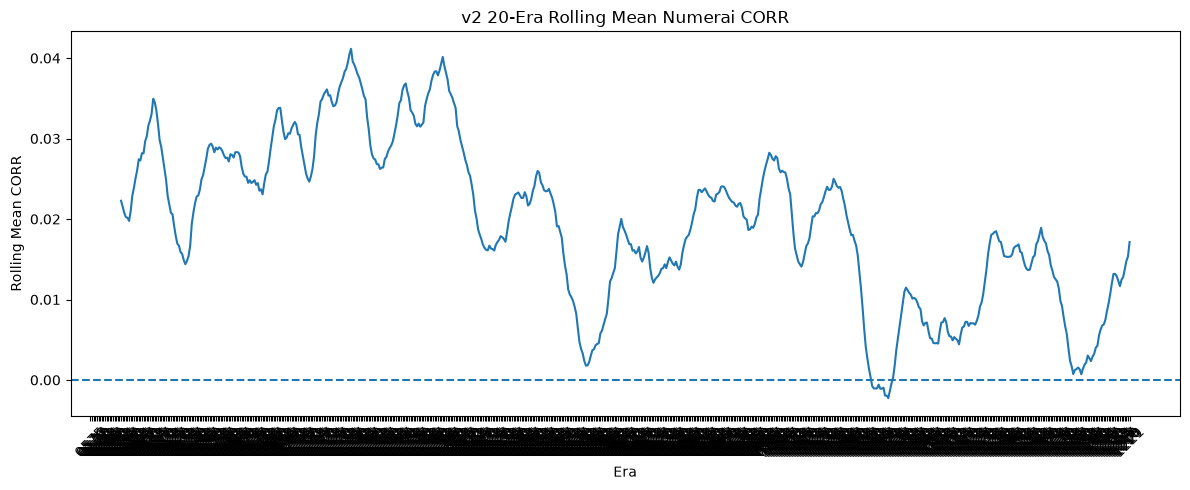

In [11]:
import matplotlib.pyplot as plt

rolling_corr_v2 = numerai_era_corr_v2.rolling(20).mean()

plt.figure(figsize=(12, 5))
plt.plot(rolling_corr_v2.index, rolling_corr_v2.values)
plt.axhline(0, linestyle="--")
plt.title("v2 20-Era Rolling Mean Numerai CORR")
plt.xlabel("Era")
plt.ylabel("Rolling Mean CORR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Save Experiment Outputs

In [13]:
from pathlib import Path
import json

OUTPUT_DIR = Path("../outputs/model_experiments")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: D:\Github Local\numerai-research\outputs\model_experiments


In [14]:
era_corr_output = pd.DataFrame({
    "era": numerai_era_corr_v2.index,
    "numerai_corr": numerai_era_corr_v2.values,
})

era_corr_path = OUTPUT_DIR / "v2_era_corr.csv"
era_corr_output.to_csv(era_corr_path, index=False)

print("Saved:", era_corr_path)

Saved: ..\outputs\model_experiments\v2_era_corr.csv


In [15]:
summary_v2 = {
    "version": "v2",
    "feature_set": "medium",
    "n_features": 780,
    "model": "LightGBM",
    "n_estimators": 500,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "mean_corr": float(mean_corr_v2),
    "corr_std": float(std_corr_v2),
    "median_corr": float(median_corr_v2),
    "sharpe_like": float(sharpe_like_v2),
    "positive_era_rate": float(positive_rate_v2),
    "min_corr": float(numerai_era_corr_v2.min()),
    "max_corr": float(numerai_era_corr_v2.max()),
}

summary_path = OUTPUT_DIR / "v2_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary_v2, f, indent=4)

print("Saved:", summary_path)

Saved: ..\outputs\model_experiments\v2_summary.json


In [16]:
model_path = OUTPUT_DIR / "v2_lightgbm.txt"

v2_model.booster_.save_model(str(model_path))

print("Saved:", model_path)

Saved: ..\outputs\model_experiments\v2_lightgbm.txt


## 11. Conclusion

Reducing the learning rate from 0.05 to 0.03 while increasing the number of boosting rounds from 300 to 500 did not improve average out-of-sample predictive performance.

Mean CORR remained essentially unchanged, decreasing slightly from 0.019724 to 0.019704. However, v2 showed modestly better stability across eras: CORR standard deviation decreased from 0.015247 to 0.015050, the Sharpe-like ratio increased from 1.294 to 1.309, and the positive-era rate increased from 89.80% to 90.26%. The worst-era CORR also improved from -0.029142 to -0.024074.

Overall, the slower boosting schedule slightly improved stability but did not generate additional average predictive signal.

Therefore, v1 remains the working benchmark, while v2 is retained as a useful alternative model for future comparison or ensemble experiments.